In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/project/initialization_shock/data/'

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
ME506s=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4').sel(time=slice('2005-05-05','2005-05-28'))

In [3]:
RP506s=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP05062/holding/geosgcm_surf/200505/*surf*200505*z.nc4').sel(time=slice('2005-05-05','2005-05-28'))

In [4]:
ME506s=ME506s.resample(time='6H').mean()
RP506s=RP506s.resample(time='6H').mean()

/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/numpy/core/_methods.py:179: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/numpy/core/_methods.py:179: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/numpy/core/_methods.py:179: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/numpy/core/_methods.py:179: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/numpy/core/_methods.py

In [5]:
ME506s=ME506s.sel(time=slice('2005-05-05','2005-05-14'))
RP506s=RP506s.sel(time=slice('2005-05-05','2005-05-14'))

In [6]:
RP5061=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP05062/holding/geosgcm_prog/200505/*prog*200505*z.nc4').sel(time=slice('2005-05-05','2005-05-28'))

In [7]:
ME5061=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_prog/200505/*prog*200505*z.nc4').sel(time=slice('2005-05-05','2005-05-28'))

In [8]:
ME5061=ME5061.sel(time=slice('2005-05-05','2005-05-14'))
RP5061=RP5061.sel(time=slice('2005-05-05','2005-05-14'))

In [9]:
ME506s=ME506s.sel(time=ME5061.time)
RP506s=RP506s.sel(time=RP5061.time)


[REGION]
  lat: -15.0 → 15.0
  lon: 140.0 → 170.0
  time window: 2005-05-06T06:00:00.000000000 → 2005-05-14T18:00:00.000000000
[dp] constructed from mid-level pressures + PS

[dp stats @ t0] min/max/mean (Pa): 0.0 101296.22500000056 2113.235612521148
[mask] below-ground masked: 0

[col_h @ t0] min/max/mean (J m-2): 8032956723.649947 9629934946.708132 9503174452.892393
[dMSEdt quick] mean/std (W m-2): -6.894234335525412e-08 1.589016321290445e-06

[LWUP] estimated from TS via σT⁴

[RADIATION sanity @ t0]
  R_toa_net     @t0 mean:  -163.77
  SW_net_sfc    @t0 mean:    33.29
  LW_down_sfc   @t0 mean:   416.63
  LWUP_sfc      @t0 mean:   468.53
  LW_net_sfc    @t0 mean:   -51.90
  R_sfc_net     @t0 mean:   -18.61
  R_col         @t0 mean:  -145.15

[TURBULENT FLUXES @ t0]
  LHFX          @t0 mean:   124.68
  SHFX          @t0 mean:     6.76

[Hnet/MSE_export @ t0]
  Hnet          @t0 mean:   -13.71
  MSE_export    @t0 mean:      nan

[SERIES SUMMARY] box-mean (W m-2)
      dMSEdt: mean=   

/var/tmp/pbs.23256135.pbspl1.nas.nasa.gov/ipykernel_75752/3611885389.py:229: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  plt.tight_layout(); plt.show()
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


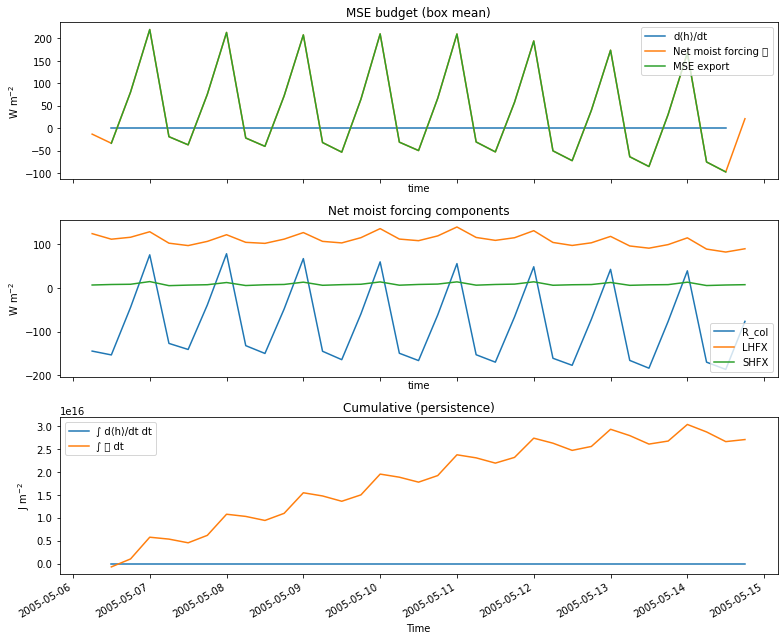

In [32]:
# ===================== GEOS–MITgcm MSE budget (with debug) ====================
# Inputs expected in memory (or uncomment open_dataset):
#   ME5061: T [K], QV [kg/kg], H [m] (mid-level height), lev [Pa]
#   ME506s: PHIS [m2 s-2], PS [Pa], SWGNET [W m-2], LWS [W m-2],
#           OLR [W m-2], LHFX [W m-2], SHFX [W m-2], SWTNET [W m-2]
# Optional for LWup estimate: TS/TSKIN/TSA/SST/SST_FOUND/TSURF
# ==============================================================================

import xarray as xr
import numpy as np

# ------------------------------- Load (edit) ----------------------------------
# ME5061 = xr.open_dataset("/path/to/3d_state.nc").chunk({"time": 1})
# ME506s = xr.open_dataset("/path/to/2d_fluxes.nc").chunk({"time": 1})

# -------------------------- Region selection helpers --------------------------
def sel_lat(ds, lat_min=None, lat_max=None):
    if lat_min is None or lat_max is None: return ds
    la = ds["lat"]
    return ds.sel(lat=slice(lat_min, lat_max)) if la[0] < la[-1] else ds.sel(lat=slice(lat_max, lat_min))

def sel_lon(ds, lon_min=None, lon_max=None):
    if lon_min is None or lon_max is None: return ds
    lo = ds["lon"]
    if lo.max() > 180: lmin, lmax = lon_min % 360, lon_max % 360
    else:              lmin, lmax = ((lon_min + 180) % 360) - 180, ((lon_max + 180) % 360) - 180
    if lmin <= lmax:
        return ds.sel(lon=slice(lmin, lmax))
    ds1 = ds.sel(lon=slice(lmin, float(lo.max())))
    ds2 = ds.sel(lon=slice(float(lo.min()), lmax))
    return xr.concat([ds1, ds2], dim="lon")

def sel_region(ds, lat_rng=None, lon_rng=None):
    out = ds
    if lat_rng is not None: out = sel_lat(out, lat_rng[0], lat_rng[1])
    if lon_rng is not None: out = sel_lon(out, lon_rng[0], lon_rng[1])
    return out

# ------------------------------- Config ---------------------------------------
LAT_RANGE = (-15.0, 15.0)   # None for global
LON_RANGE = (140.0, 170.0)  # None for global
state3d = sel_region(ME5061, LAT_RANGE, LON_RANGE)
flux2d  = sel_region(ME506s, LAT_RANGE, LON_RANGE)

print("\n[REGION]")
print("  lat:", float(state3d.lat.min()), "→", float(state3d.lat.max()))
print("  lon:", float(state3d.lon.min()), "→", float(state3d.lon.max()))
print("  time window:", str(state3d.time.min().values), "→", str(state3d.time.max().values))

# ------------------------------- Constants ------------------------------------
g  = 9.81
cp = 1004.0
Lv = 2.5e6
sigma = 5.670374419e-8  # Stefan–Boltzmann

# ----------------------- Vertical dim + dp construction -----------------------
def get_lev_dim(ds3d):
    for cand in ("lev", "plev", "level"):
        if cand in ds3d.dims: return cand
    raise ValueError("No vertical level dim found (lev/plev/level).")

def build_dp_positional(ds3d, ps_2d):
    lev_dim = get_lev_dim(ds3d)
    # A) DELP
    for key in ("DELP","delp","Dp","dP"):
        if key in ds3d:
            dp = ds3d[key]
            if lev_dim not in dp.dims: raise ValueError(f"{key} present but missing '{lev_dim}' dim.")
            print("[dp] using DELP from dataset"); return dp
    # B) bounds
    for key in ("lev_bnds","plev_bnds","p_bnds","pbnds"):
        if key in ds3d:
            pb = ds3d[key]; bdim = "bnds" if "bnds" in pb.dims else ("bound" if "bound" in pb.dims else "nbnds")
            print("[dp] using pressure bounds:", key)
            return pb.isel({bdim:1}) - pb.isel({bdim:0})
    # C) construct by position (tolerates duplicate lev values)
    lev_vals = ds3d[lev_dim].values; nlev = int(len(lev_vals))
    if nlev < 2: raise ValueError("Need ≥2 levels to construct interfaces.")
    p_top = 100.0  # Pa
    p_up_1d = np.empty((nlev,), dtype=float); p_dn_1d = np.empty((nlev-1,), dtype=float)
    p_up_1d[0] = p_top
    for k in range(1, nlev):   p_up_1d[k] = 0.5*(lev_vals[k-1] + lev_vals[k])
    for k in range(0, nlev-1): p_dn_1d[k] = 0.5*(lev_vals[k] + lev_vals[k+1])
    tmpl = ds3d["T"]
    p_up = xr.DataArray(p_up_1d, dims=(lev_dim,)).broadcast_like(tmpl)
    p_dn = xr.concat([
        xr.DataArray(p_dn_1d, dims=(lev_dim,)).broadcast_like(tmpl.isel({lev_dim: slice(0, nlev-1)})),
        xr.zeros_like(tmpl.isel({lev_dim: -1})) + ps_2d
    ], dim=lev_dim)
    print("[dp] constructed from mid-level pressures + PS")
    return p_dn - p_up

lev_dim = get_lev_dim(state3d)
dp = build_dp_positional(state3d, flux2d["PS"]).clip(min=0)

print("\n[dp stats @ t0] min/max/mean (Pa):",
      float(dp.isel(time=0).min()), float(dp.isel(time=0).max()), float(dp.isel(time=0).mean()))

# Mask sub-surface levels: p_mid > PS
p_mid_vals = state3d[lev_dim].values
p_mid_4d = xr.DataArray(p_mid_vals, dims=(lev_dim,)).broadcast_like(state3d["T"])
below_ground = p_mid_4d > flux2d["PS"]
n_bg = int(below_ground.sum().compute())
print("[mask] below-ground masked:", n_bg)
for v in ("T","QV"): state3d[v] = state3d[v].where(~below_ground)

# --------------------- Geopotential from mid-level height H -------------------
H = state3d["H"]
if lev_dim not in H.dims: raise ValueError(f"'H' must share '{lev_dim}'. Found: {H.dims}")
Phi = g * H  # if H is already geopotential, set Phi = H

# ----------------- Column MSE (J/m^2) and tendency (W/m^2) -------------------
T  = state3d["T"]; q = state3d["QV"]
h = cp*T + Lv*q + Phi
col_h = (h * dp / g).sum(lev_dim)

time = col_h["time"]
dt_sec = (time.shift(time=-1) - time).astype("timedelta64[s]").astype(float)
dMSEdt = (col_h.shift(time=-1) - col_h.shift(time=+1)) / (2.0*dt_sec)

print("\n[col_h @ t0] min/max/mean (J m-2):",
      float(col_h.isel(time=0).min()), float(col_h.isel(time=0).max()), float(col_h.isel(time=0).mean()))
print("[dMSEdt quick] mean/std (W m-2):",
      float(dMSEdt.mean()), float(dMSEdt.std()))

# ---------------------- Radiation: build R_col correctly ----------------------
SWTNET = flux2d["SWTNET"]     # TOA SW net, downward +
OLR    = flux2d["OLR"]        # TOA LW up, +
SWGNET = flux2d["SWGNET"]     # Surface SW net, downward +
LWS_dn = flux2d["LWS"]        # Surface LW down (absorbed at sfc), ~ LW↓

# find or estimate surface LW up
def find_surface_temp(ds3d, ds2d):
    for name in ("TS","TSKIN","TSA","SST","SST_FOUND","TSURF","T2M"):
        if name in ds2d: return ds2d[name]
        if name in ds3d: return ds3d[name]
    raise ValueError("Need a surface/skin temperature for LW↑ estimate (TS/TSKIN/SST/...).")

lwup_names = [n for n in ("LWUP","LWUP_SFC","LWGUP","LWSUP","LWGEM") if n in flux2d.variables]
if lwup_names:
    LWUP_sfc = flux2d[lwup_names[0]]
    print(f"\n[LWUP] using '{lwup_names[0]}' from file")
else:
    Tsurf = find_surface_temp(state3d, flux2d)  # K
    LWUP_sfc = sigma * Tsurf**4
    print(f"\n[LWUP] estimated from {Tsurf.name} via σT⁴")

LW_net_sfc = LWS_dn - LWUP_sfc         # (down − up), + into surface
SW_net_sfc = SWGNET                    # already (down − up), + into surface
R_sfc_net  = SW_net_sfc + LW_net_sfc   # + into surface

R_toa_net  = SWTNET - OLR              # + into atmosphere
R_col      = R_toa_net - R_sfc_net     # + warms atmosphere

def snap(name, da): print(f"  {name:14s}@t0 mean: {float(da.isel(time=0).mean().compute()):8.2f}")
print("\n[RADIATION sanity @ t0]")
snap("R_toa_net", R_toa_net); snap("SW_net_sfc", SW_net_sfc); snap("LW_down_sfc", LWS_dn)
snap("LWUP_sfc", LWUP_sfc); snap("LW_net_sfc", LW_net_sfc); snap("R_sfc_net", R_sfc_net); snap("R_col", R_col)

# ------------------------- Turbulent fluxes (atm +) ---------------------------
def ensure_atm_positive(da, name):
    m = float(da.isel(time=0).mean().compute())
    if m < 0: print(f"  -> flipping {name} sign to atmosphere-positive"); return -da
    return da

print("\n[TURBULENT FLUXES @ t0]")
LHF = ensure_atm_positive(flux2d["LHFX"], "LHFX")
SHF = ensure_atm_positive(flux2d["SHFX"], "SHFX")
snap("LHFX", LHF); snap("SHFX", SHF)

# ------------------------------- Final terms ----------------------------------
Hnet = R_col + LHF + SHF
MSE_export = Hnet - dMSEdt

print("\n[Hnet/MSE_export @ t0]")
snap("Hnet", Hnet); snap("MSE_export", MSE_export)

# ------------------- Area-weighted (cos lat) box means ------------------------
wlat = np.cos(np.deg2rad(flux2d["lat"])); wlat = wlat / wlat.mean()
def box_mean(da): return (da * wlat).mean(("lat","lon"))

series = xr.Dataset({
    "dMSEdt"    : box_mean(dMSEdt),
    "Hnet"      : box_mean(Hnet),
    "R_col"     : box_mean(R_col),
    "LHFX"      : box_mean(LHF),
    "SHFX"      : box_mean(SHF),
    "MSE_export": box_mean(MSE_export),
}).persist()

print("\n[SERIES SUMMARY] box-mean (W m-2)")
for k in series:
    print(f"  {k:>10s}: mean={float(series[k].mean().compute()):8.2f}, std={float(series[k].std().compute()):8.2f}")

closure = (series["dMSEdt"] - (series["Hnet"] - series["MSE_export"]))
print("\n[CLOSURE] dMSEdt - (Hnet - export) (W m-2):",
      "mean=", float(closure.mean().compute()), " std=", float(closure.std().compute()))

# ------------------------------- Quick plots ----------------------------------
try:
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

    ax = axs[0]
    series["dMSEdt"].plot(ax=ax, label="d⟨h⟩/dt")
    series["Hnet"].plot(ax=ax, label="Net moist forcing 𝓗")
    series["MSE_export"].plot(ax=ax, label="MSE export")
    ax.set_ylabel("W m$^{-2}$"); ax.legend(); ax.set_title("MSE budget (box mean)")

    ax = axs[1]
    series["R_col"].plot(ax=ax, label="R_col")
    series["LHFX"].plot(ax=ax, label="LHFX")
    series["SHFX"].plot(ax=ax, label="SHFX")
    ax.set_ylabel("W m$^{-2}$"); ax.legend(); ax.set_title("Net moist forcing components")

    # Cumulative with variable dt (rectangle rule)
    dt = series.time.diff("time").astype("timedelta64[s]").astype(float)
    dt = dt.pad(time=(1,0)).fillna(dt.isel(time=0))
    cum_dMSE = (series["dMSEdt"] * dt).cumsum("time")
    cum_Hnet = (series["Hnet"]   * dt).cumsum("time")

    ax = axs[2]
    cum_dMSE.plot(ax=ax, label="∫ d⟨h⟩/dt dt")
    cum_Hnet.plot(ax=ax, label="∫ 𝓗 dt")
    ax.set_ylabel("J m$^{-2}$"); ax.legend(); ax.set_title("Cumulative (persistence)")
    ax.set_xlabel("Time")

    plt.tight_layout(); plt.show()
except Exception as e:
    print("[plot skipped]", e)


[POINT] requested (lon,lat)=(143.00,-1.00) → selected grid (lon,lat)=(143.00,-1.00)
[POINT closure] mean= 1.9707784580414926e-15  std= 6.3982085273027415e-15


/var/tmp/pbs.23256135.pbspl1.nas.nasa.gov/ipykernel_75752/1817034084.py:75: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  plt.tight_layout(rect=[0,0,1,0.96])
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


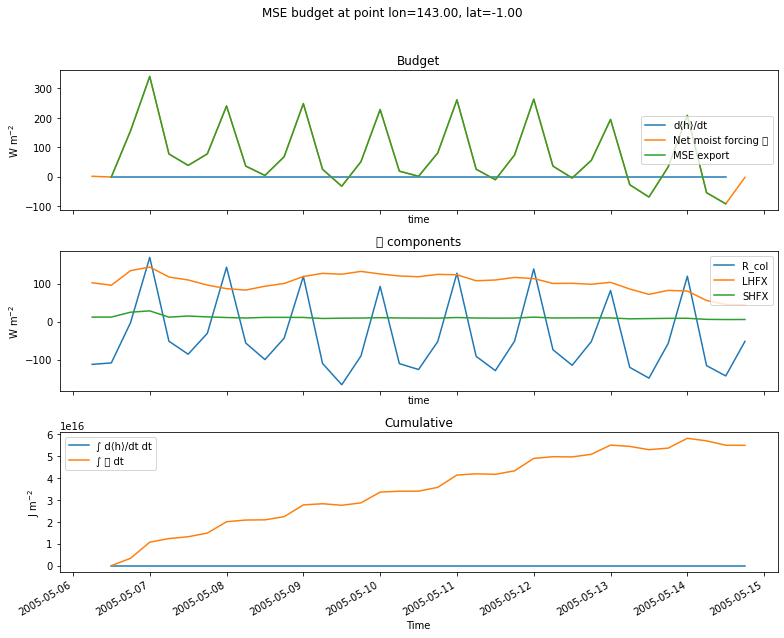

In [33]:
# ======================= Point selection & plots ========================
# Target point (requested)
PT_LON, PT_LAT = 143.0, -1.0

# Robust lon handling (0–360 vs −180–180)
def _canon_lon(val, ds_lon):
    if ds_lon.max() > 180:
        return val % 360.0
    return ((val + 180.0) % 360.0) - 180.0

lon_c = _canon_lon(PT_LON, ME506s.lon)

# Select nearest grid point from any field with (time, lat, lon) dims
# Use Hnet as the template (but any of your budget fields works)
pt_sel = dict(lat=PT_LAT, lon=lon_c, method="nearest")

# Slice each series at the point
pt_series = xr.Dataset({
    "dMSEdt"    : dMSEdt.sel(**pt_sel),
    "Hnet"      : Hnet.sel(**pt_sel),
    "R_col"     : R_col.sel(**pt_sel),
    "LHFX"      : LHF.sel(**pt_sel),
    "SHFX"      : SHF.sel(**pt_sel),
    "MSE_export": MSE_export.sel(**pt_sel),
})


ME=pt_series.copy()
ME=ME.compute()
# Report the actual coordinates chosen
lat_actual = float(pt_series["Hnet"]["lat"].values)
lon_actual = float(pt_series["Hnet"]["lon"].values)
print(f"[POINT] requested (lon,lat)=({PT_LON:.2f},{PT_LAT:.2f}) "
      f"→ selected grid (lon,lat)=({lon_actual:.2f},{lat_actual:.2f})")

# Quick sanity + closure at the point
closure_pt = pt_series["dMSEdt"] - (pt_series["Hnet"] - pt_series["MSE_export"])
print("[POINT closure] mean=", float(closure_pt.mean().compute()),
      " std=", float(closure_pt.std().compute()))

# ------------------------------ Plots ---------------------------------
try:
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    fig.suptitle(f"MSE budget at point lon={lon_actual:.2f}, lat={lat_actual:.2f}", y=0.98)

    # Panel 1: budget
    ax = axs[0]
    pt_series["dMSEdt"].plot(ax=ax, label="d⟨h⟩/dt")
    pt_series["Hnet"].plot(ax=ax, label="Net moist forcing 𝓗")
    pt_series["MSE_export"].plot(ax=ax, label="MSE export")
    ax.set_ylabel("W m$^{-2}$"); ax.legend(); ax.set_title("Budget")

    # Panel 2: components
    ax = axs[1]
    pt_series["R_col"].plot(ax=ax, label="R_col")
    pt_series["LHFX"].plot(ax=ax, label="LHFX")
    pt_series["SHFX"].plot(ax=ax, label="SHFX")
    ax.set_ylabel("W m$^{-2}$"); ax.legend(); ax.set_title("𝓗 components")

    # Panel 3: cumulative (rectangle rule)
    t = pt_series.time
    dt = t.diff("time").astype("timedelta64[s]").astype(float)
    dt = dt.pad(time=(1,0)).fillna(dt.isel(time=0))
    cum_dMSE = (pt_series["dMSEdt"] * dt).cumsum("time")
    cum_Hnet = (pt_series["Hnet"]   * dt).cumsum("time")

    ax = axs[2]
    cum_dMSE.plot(ax=ax, label="∫ d⟨h⟩/dt dt")
    cum_Hnet.plot(ax=ax, label="∫ 𝓗 dt")
    ax.set_ylabel("J m$^{-2}$"); ax.legend(); ax.set_title("Cumulative")
    ax.set_xlabel("Time")

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()
except Exception as e:
    print("[plot skipped]", e)



[REGION]
  lat: -15.0 → 15.0
  lon: 140.0 → 170.0
  time window: 2005-05-06T06:00:00.000000000 → 2005-05-14T18:00:00.000000000
[dp] constructed from mid-level pressures + PS

[dp stats @ t0] min/max/mean (Pa): 0.0 101242.24062500056 2113.09900656869
[mask] below-ground masked: 0

[col_h @ t0] min/max/mean (J m-2): 7983929212.096604 9549225877.249153 9446055178.96742
[dMSEdt quick] mean/std (W m-2): 7.9801998689101e-08 1.7389618908739388e-06

[LWUP] estimated from TS via σT⁴

[RADIATION sanity @ t0]
  R_toa_net     @t0 mean:  -157.63
  SW_net_sfc    @t0 mean:    28.17
  LW_down_sfc   @t0 mean:   420.06
  LWUP_sfc      @t0 mean:   469.97
  LW_net_sfc    @t0 mean:   -49.92
  R_sfc_net     @t0 mean:   -21.74
  R_col         @t0 mean:  -135.89

[TURBULENT FLUXES @ t0]
  LHFX          @t0 mean:   122.91
  SHFX          @t0 mean:     6.78

[Hnet/MSE_export @ t0]
  Hnet          @t0 mean:    -6.20
  MSE_export    @t0 mean:      nan

[SERIES SUMMARY] box-mean (W m-2)
      dMSEdt: mean=    0.0

/var/tmp/pbs.23256135.pbspl1.nas.nasa.gov/ipykernel_75752/3568290065.py:235: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  plt.tight_layout(); plt.show()
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


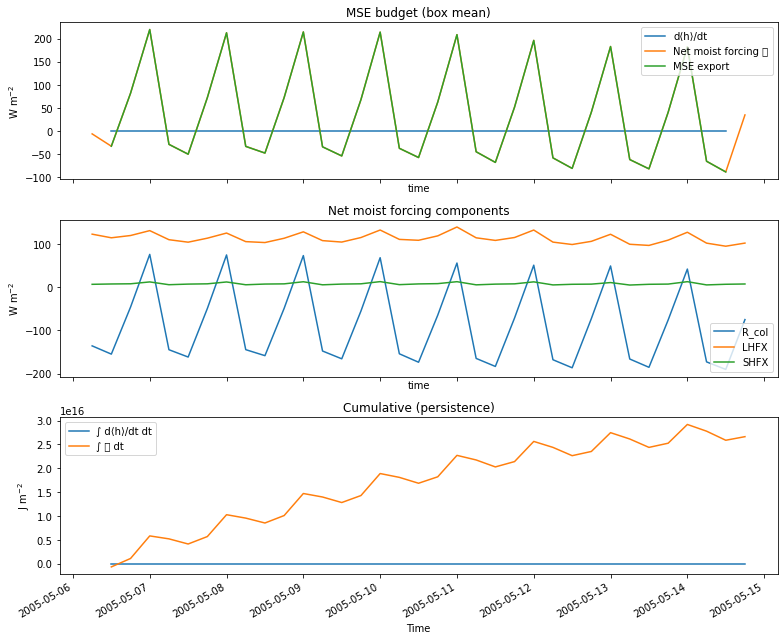

In [34]:
# ===================== GEOS–MITgcm MSE budget (with debug) ====================
# Inputs expected in memory (or uncomment open_dataset):
#   RP5061: T [K], QV [kg/kg], H [m] (mid-level height), lev [Pa]
#   RP506s: PHIS [m2 s-2], PS [Pa], SWGNET [W m-2], LWS [W m-2],
#           OLR [W m-2], LHFX [W m-2], SHFX [W m-2], SWTNET [W m-2]
# Optional for LWup estimate: TS/TSKIN/TSA/SST/SST_FOUND/TSURF
# ==============================================================================

import xarray as xr
import numpy as np

# ------------------------------- Load (edit) ----------------------------------
# RP5061 = xr.open_dataset("/path/to/3d_state.nc").chunk({"time": 1})
# RP506s = xr.open_dataset("/path/to/2d_fluxes.nc").chunk({"time": 1})

# -------------------------- Region selection helpers --------------------------
def sel_lat(ds, lat_min=None, lat_max=None):
    if lat_min is None or lat_max is None: return ds
    la = ds["lat"]
    return ds.sel(lat=slice(lat_min, lat_max)) if la[0] < la[-1] else ds.sel(lat=slice(lat_max, lat_min))

def sel_lon(ds, lon_min=None, lon_max=None):
    if lon_min is None or lon_max is None: return ds
    lo = ds["lon"]
    if lo.max() > 180: lmin, lmax = lon_min % 360, lon_max % 360
    else:              lmin, lmax = ((lon_min + 180) % 360) - 180, ((lon_max + 180) % 360) - 180
    if lmin <= lmax:
        return ds.sel(lon=slice(lmin, lmax))
    ds1 = ds.sel(lon=slice(lmin, float(lo.max())))
    ds2 = ds.sel(lon=slice(float(lo.min()), lmax))
    return xr.concat([ds1, ds2], dim="lon")

def sel_region(ds, lat_rng=None, lon_rng=None):
    out = ds
    if lat_rng is not None: out = sel_lat(out, lat_rng[0], lat_rng[1])
    if lon_rng is not None: out = sel_lon(out, lon_rng[0], lon_rng[1])
    return out

# ------------------------------- Config ---------------------------------------
LAT_RANGE = (-15.0, 15.0)   # None for global
LON_RANGE = (140.0, 170.0)  # None for global
state3d = sel_region(RP5061, LAT_RANGE, LON_RANGE)
flux2d  = sel_region(RP506s, LAT_RANGE, LON_RANGE)

print("\n[REGION]")
print("  lat:", float(state3d.lat.min()), "→", float(state3d.lat.max()))
print("  lon:", float(state3d.lon.min()), "→", float(state3d.lon.max()))
print("  time window:", str(state3d.time.min().values), "→", str(state3d.time.max().values))

# ------------------------------- Constants ------------------------------------
g  = 9.81
cp = 1004.0
Lv = 2.5e6
sigma = 5.670374419e-8  # Stefan–Boltzmann

# ----------------------- Vertical dim + dp construction -----------------------
def get_lev_dim(ds3d):
    for cand in ("lev", "plev", "level"):
        if cand in ds3d.dims: return cand
    raise ValueError("No vertical level dim found (lev/plev/level).")

def build_dp_positional(ds3d, ps_2d):
    lev_dim = get_lev_dim(ds3d)
    # A) DELP
    for key in ("DELP","delp","Dp","dP"):
        if key in ds3d:
            dp = ds3d[key]
            if lev_dim not in dp.dims: raise ValueError(f"{key} present but missing '{lev_dim}' dim.")
            print("[dp] using DELP from dataset"); return dp
    # B) bounds
    for key in ("lev_bnds","plev_bnds","p_bnds","pbnds"):
        if key in ds3d:
            pb = ds3d[key]; bdim = "bnds" if "bnds" in pb.dims else ("bound" if "bound" in pb.dims else "nbnds")
            print("[dp] using pressure bounds:", key)
            return pb.isel({bdim:1}) - pb.isel({bdim:0})
    # C) construct by position (tolerates duplicate lev values)
    lev_vals = ds3d[lev_dim].values; nlev = int(len(lev_vals))
    if nlev < 2: raise ValueError("Need ≥2 levels to construct interfaces.")
    p_top = 100.0  # Pa
    p_up_1d = np.empty((nlev,), dtype=float); p_dn_1d = np.empty((nlev-1,), dtype=float)
    p_up_1d[0] = p_top
    for k in range(1, nlev):   p_up_1d[k] = 0.5*(lev_vals[k-1] + lev_vals[k])
    for k in range(0, nlev-1): p_dn_1d[k] = 0.5*(lev_vals[k] + lev_vals[k+1])
    tmpl = ds3d["T"]
    p_up = xr.DataArray(p_up_1d, dims=(lev_dim,)).broadcast_like(tmpl)
    p_dn = xr.concat([
        xr.DataArray(p_dn_1d, dims=(lev_dim,)).broadcast_like(tmpl.isel({lev_dim: slice(0, nlev-1)})),
        xr.zeros_like(tmpl.isel({lev_dim: -1})) + ps_2d
    ], dim=lev_dim)
    print("[dp] constructed from mid-level pressures + PS")
    return p_dn - p_up

lev_dim = get_lev_dim(state3d)
dp = build_dp_positional(state3d, flux2d["PS"]).clip(min=0)

print("\n[dp stats @ t0] min/max/mean (Pa):",
      float(dp.isel(time=0).min()), float(dp.isel(time=0).max()), float(dp.isel(time=0).mean()))

# Mask sub-surface levels: p_mid > PS
p_mid_vals = state3d[lev_dim].values
p_mid_4d = xr.DataArray(p_mid_vals, dims=(lev_dim,)).broadcast_like(state3d["T"])
below_ground = p_mid_4d > flux2d["PS"]
n_bg = int(below_ground.sum().compute())
print("[mask] below-ground masked:", n_bg)
for v in ("T","QV"): state3d[v] = state3d[v].where(~below_ground)

# --------------------- Geopotential from mid-level height H -------------------
H = state3d["H"]
if lev_dim not in H.dims: raise ValueError(f"'H' must share '{lev_dim}'. Found: {H.dims}")
Phi = g * H  # if H is already geopotential, set Phi = H

# ----------------- Column MSE (J/m^2) and tendency (W/m^2) -------------------
T  = state3d["T"]; q = state3d["QV"]
h = cp*T + Lv*q + Phi
col_h = (h * dp / g).sum(lev_dim)

time = col_h["time"]
dt_sec = (time.shift(time=-1) - time).astype("timedelta64[s]").astype(float)
dMSEdt = (col_h.shift(time=-1) - col_h.shift(time=+1)) / (2.0*dt_sec)

print("\n[col_h @ t0] min/max/mean (J m-2):",
      float(col_h.isel(time=0).min()), float(col_h.isel(time=0).max()), float(col_h.isel(time=0).mean()))
print("[dMSEdt quick] mean/std (W m-2):",
      float(dMSEdt.mean()), float(dMSEdt.std()))

# ---------------------- Radiation: build R_col correctly ----------------------
SWTNET = flux2d["SWTNET"]     # TOA SW net, downward +
OLR    = flux2d["OLR"]        # TOA LW up, +
SWGNET = flux2d["SWGNET"]     # Surface SW net, downward +
LWS_dn = flux2d["LWS"]        # Surface LW down (absorbed at sfc), ~ LW↓

# find or estimate surface LW up
def find_surface_temp(ds3d, ds2d):
    for name in ("TS","TSKIN","TSA","SST","SST_FOUND","TSURF","T2M"):
        if name in ds2d: return ds2d[name]
        if name in ds3d: return ds3d[name]
    raise ValueError("Need a surface/skin temperature for LW↑ estimate (TS/TSKIN/SST/...).")

lwup_names = [n for n in ("LWUP","LWUP_SFC","LWGUP","LWSUP","LWGEM") if n in flux2d.variables]
if lwup_names:
    LWUP_sfc = flux2d[lwup_names[0]]
    print(f"\n[LWUP] using '{lwup_names[0]}' from file")
else:
    Tsurf = find_surface_temp(state3d, flux2d)  # K
    LWUP_sfc = sigma * Tsurf**4
    print(f"\n[LWUP] estimated from {Tsurf.name} via σT⁴")

LW_net_sfc = LWS_dn - LWUP_sfc         # (down − up), + into surface
SW_net_sfc = SWGNET                    # already (down − up), + into surface
R_sfc_net  = SW_net_sfc + LW_net_sfc   # + into surface

R_toa_net  = SWTNET - OLR              # + into atmosphere
R_col      = R_toa_net - R_sfc_net     # + warms atmosphere

def snap(name, da): print(f"  {name:14s}@t0 mean: {float(da.isel(time=0).mean().compute()):8.2f}")
print("\n[RADIATION sanity @ t0]")
snap("R_toa_net", R_toa_net); snap("SW_net_sfc", SW_net_sfc); snap("LW_down_sfc", LWS_dn)
snap("LWUP_sfc", LWUP_sfc); snap("LW_net_sfc", LW_net_sfc); snap("R_sfc_net", R_sfc_net); snap("R_col", R_col)

# ------------------------- Turbulent fluxes (atm +) ---------------------------
def ensure_atm_positive(da, name):
    m = float(da.isel(time=0).mean().compute())
    if m < 0: print(f"  -> flipping {name} sign to atmosphere-positive"); return -da
    return da

print("\n[TURBULENT FLUXES @ t0]")
LHF = ensure_atm_positive(flux2d["LHFX"], "LHFX")
SHF = ensure_atm_positive(flux2d["SHFX"], "SHFX")
snap("LHFX", LHF); snap("SHFX", SHF)

# ------------------------------- Final terms ----------------------------------
Hnet = R_col + LHF + SHF
MSE_export = Hnet - dMSEdt

print("\n[Hnet/MSE_export @ t0]")
snap("Hnet", Hnet); snap("MSE_export", MSE_export)

# ------------------- Area-weighted (cos lat) box means ------------------------
wlat = np.cos(np.deg2rad(flux2d["lat"])); wlat = wlat / wlat.mean()
def box_mean(da): return (da * wlat).mean(("lat","lon"))

series = xr.Dataset({
    "dMSEdt"    : box_mean(dMSEdt),
    "Hnet"      : box_mean(Hnet),
    "R_col"     : box_mean(R_col),
    "LHFX"      : box_mean(LHF),
    "SHFX"      : box_mean(SHF),
    "MSE_export": box_mean(MSE_export),
}).persist()


RP=series.copy()
RP=RP.compute()



print("\n[SERIES SUMMARY] box-mean (W m-2)")
for k in series:
    print(f"  {k:>10s}: mean={float(series[k].mean().compute()):8.2f}, std={float(series[k].std().compute()):8.2f}")

closure = (series["dMSEdt"] - (series["Hnet"] - series["MSE_export"]))
print("\n[CLOSURE] dMSEdt - (Hnet - export) (W m-2):",
      "mean=", float(closure.mean().compute()), " std=", float(closure.std().compute()))

# ------------------------------- Quick plots ----------------------------------
try:
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

    ax = axs[0]
    series["dMSEdt"].plot(ax=ax, label="d⟨h⟩/dt")
    series["Hnet"].plot(ax=ax, label="Net moist forcing 𝓗")
    series["MSE_export"].plot(ax=ax, label="MSE export")
    ax.set_ylabel("W m$^{-2}$"); ax.legend(); ax.set_title("MSE budget (box mean)")

    ax = axs[1]
    series["R_col"].plot(ax=ax, label="R_col")
    series["LHFX"].plot(ax=ax, label="LHFX")
    series["SHFX"].plot(ax=ax, label="SHFX")
    ax.set_ylabel("W m$^{-2}$"); ax.legend(); ax.set_title("Net moist forcing components")

    # Cumulative with variable dt (rectangle rule)
    dt = series.time.diff("time").astype("timedelta64[s]").astype(float)
    dt = dt.pad(time=(1,0)).fillna(dt.isel(time=0))
    cum_dMSE = (series["dMSEdt"] * dt).cumsum("time")
    cum_Hnet = (series["Hnet"]   * dt).cumsum("time")

    ax = axs[2]
    cum_dMSE.plot(ax=ax, label="∫ d⟨h⟩/dt dt")
    cum_Hnet.plot(ax=ax, label="∫ 𝓗 dt")
    ax.set_ylabel("J m$^{-2}$"); ax.legend(); ax.set_title("Cumulative (persistence)")
    ax.set_xlabel("Time")

    plt.tight_layout(); plt.show()
except Exception as e:
    print("[plot skipped]", e)


[POINT] requested (lon,lat)=(143.00,-1.00) → selected grid (lon,lat)=(143.00,-1.00)
[POINT closure] mean= 8.32412063698353e-18  std= 6.559945716794102e-15


/var/tmp/pbs.23256135.pbspl1.nas.nasa.gov/ipykernel_75752/2164136832.py:77: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  plt.tight_layout(rect=[0,0,1,0.96])
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 120023 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL H}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


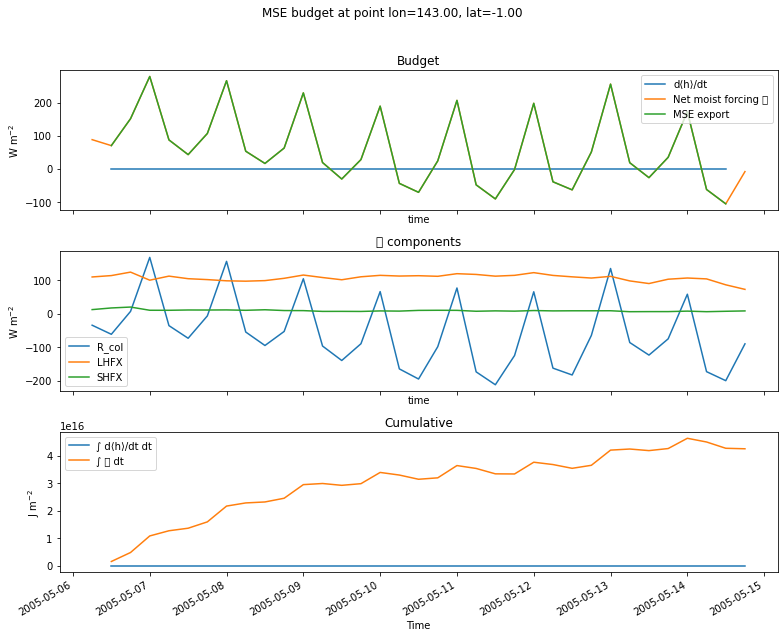

In [36]:
# ======================= Point selection & plots ========================
# Target point (requested)
PT_LON, PT_LAT = 143.0, -1.0

# Robust lon handling (0–360 vs −180–180)
def _canon_lon(val, ds_lon):
    if ds_lon.max() > 180:
        return val % 360.0
    return ((val + 180.0) % 360.0) - 180.0

lon_c = _canon_lon(PT_LON, ME506s.lon)

# Select nearest grid point from any field with (time, lat, lon) dims
# Use Hnet as the template (but any of your budget fields works)
pt_sel = dict(lat=PT_LAT, lon=lon_c, method="nearest")

# Slice each series at the point
pt_series = xr.Dataset({
    "dMSEdt"    : dMSEdt.sel(**pt_sel),
    "Hnet"      : Hnet.sel(**pt_sel),
    "R_col"     : R_col.sel(**pt_sel),
    "LHFX"      : LHF.sel(**pt_sel),
    "SHFX"      : SHF.sel(**pt_sel),
    "MSE_export": MSE_export.sel(**pt_sel),
})


RP=pt_series.copy()
RP=RP.compute()


# Report the actual coordinates chosen
lat_actual = float(pt_series["Hnet"]["lat"].values)
lon_actual = float(pt_series["Hnet"]["lon"].values)
print(f"[POINT] requested (lon,lat)=({PT_LON:.2f},{PT_LAT:.2f}) "
      f"→ selected grid (lon,lat)=({lon_actual:.2f},{lat_actual:.2f})")

# Quick sanity + closure at the point
closure_pt = pt_series["dMSEdt"] - (pt_series["Hnet"] - pt_series["MSE_export"])
print("[POINT closure] mean=", float(closure_pt.mean().compute()),
      " std=", float(closure_pt.std().compute()))

# ------------------------------ Plots ---------------------------------
try:
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    fig.suptitle(f"MSE budget at point lon={lon_actual:.2f}, lat={lat_actual:.2f}", y=0.98)

    # Panel 1: budget
    ax = axs[0]
    pt_series["dMSEdt"].plot(ax=ax, label="d⟨h⟩/dt")
    pt_series["Hnet"].plot(ax=ax, label="Net moist forcing 𝓗")
    pt_series["MSE_export"].plot(ax=ax, label="MSE export")
    ax.set_ylabel("W m$^{-2}$"); ax.legend(); ax.set_title("Budget")

    # Panel 2: components
    ax = axs[1]
    pt_series["R_col"].plot(ax=ax, label="R_col")
    pt_series["LHFX"].plot(ax=ax, label="LHFX")
    pt_series["SHFX"].plot(ax=ax, label="SHFX")
    ax.set_ylabel("W m$^{-2}$"); ax.legend(); ax.set_title("𝓗 components")

    # Panel 3: cumulative (rectangle rule)
    t = pt_series.time
    dt = t.diff("time").astype("timedelta64[s]").astype(float)
    dt = dt.pad(time=(1,0)).fillna(dt.isel(time=0))
    cum_dMSE = (pt_series["dMSEdt"] * dt).cumsum("time")
    cum_Hnet = (pt_series["Hnet"]   * dt).cumsum("time")

    ax = axs[2]
    cum_dMSE.plot(ax=ax, label="∫ d⟨h⟩/dt dt")
    cum_Hnet.plot(ax=ax, label="∫ 𝓗 dt")
    ax.set_ylabel("J m$^{-2}$"); ax.legend(); ax.set_title("Cumulative")
    ax.set_xlabel("Time")

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()
except Exception as e:
    print("[plot skipped]", e)


In [38]:
RP12=RP.resample(time='12H').mean()
ME12=ME.resample(time='12H').mean()

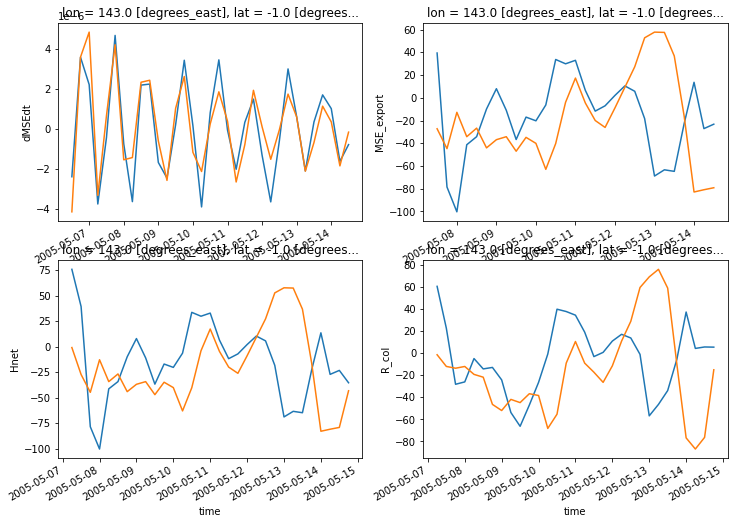

In [53]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)

ME.dMSEdt.plot()
RP.dMSEdt.plot()


d=4
plt.subplot(2,2,2)
(ME.MSE_export[d:]-ME.MSE_export[:-d].data).plot()
(RP.MSE_export[d:]-RP.MSE_export[:-d].data).plot()
#RP.MSE_export.plot()

plt.subplot(2,2,3)
(ME.Hnet[d:]-ME.Hnet[:-d].data).plot()
(RP.Hnet[d:]-RP.Hnet[:-d].data).plot()
# ME.Hnet.plot()
# RP.Hnet.plot()

plt.subplot(2,2,4)

(ME.R_col[d:]-ME.R_col[:-d].data).plot()
(RP.R_col[d:]-RP.R_col[:-d].data).plot()


# ME.R_col.plot()
# RP.R_col.plot()

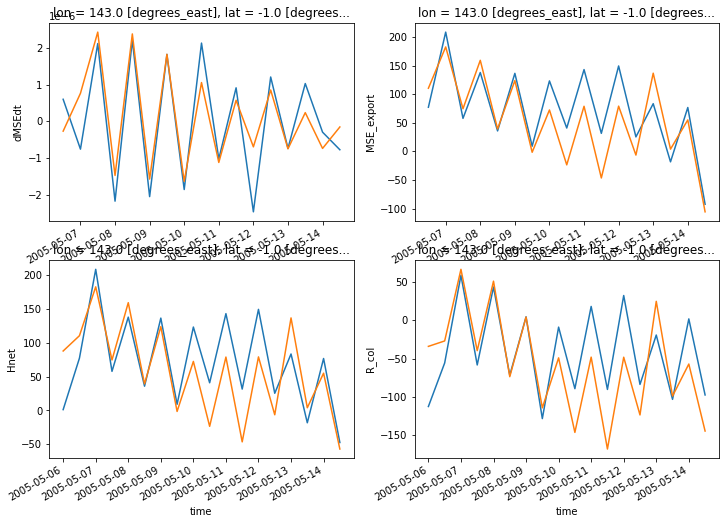

In [41]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)

ME12.dMSEdt.plot()
RP12.dMSEdt.plot()


plt.subplot(2,2,2)
ME12.MSE_export.plot()
RP12.MSE_export.plot()

plt.subplot(2,2,3)
ME12.Hnet.plot()
RP12.Hnet.plot()

plt.subplot(2,2,4)
ME12.R_col.plot()
RP12.R_col.plot()